# Step 1: Environment Setup

# 🦠 Hybrid Epidemiological Modeling: SIR + Deep Learning
This notebook develops a hybrid forecasting model that combines the theoretical laws of biology with the pattern-recognition capabilities of deep learning.

## 🛠️ 1. Environment Setup
To build this hybrid architecture, we need a diverse stack of libraries. We are essentially bridging three different worlds of computation:
*   **Data Manipulation:** `numpy` and `pandas` for handling arrays and dataframes.
*   **Mathematical Physics:** `scipy.integrate` (to solve our differential equations) and `scipy.optimize` (to find the perfect mathematical parameters).
*   **Machine Learning:** `scikit-learn` for data preprocessing/metrics, and `TensorFlow/Keras` to build the Deep Neural Network.

In [1]:
# Import numerical and dataframe handling libraries
import numpy as np
import pandas as pd

# Import visualization tool
import matplotlib.pyplot as plt

# Import differential equation solver and optimizer
from scipy.integrate import odeint
from scipy.optimize import minimize

# Import machine learning data prep and metric tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Import deep learning framework
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Data Loading & Initialization

## 📥 2. Data Ingestion & Initial State ($t=0$)
A differential equation requires an **initial value** to start calculating the future. 

In epidemiology, Day 0 ($t=0$) is the anchor point of the entire simulation. We load our historical dataset and extract the exact starting populations to define our initial state vector, $y_0$:

$$ y_0 = [S(0), I(0), R(0)] $$

*   **$S(0)$**: The initial number of people who *could* catch the disease.
*   **$I(0)$**: The initial number of people who are *actively* infected.
*   **$R(0)$**: The initial number of people who have already *recovered* (usually 0 at the start of an outbreak).

In [2]:
# Load the dataset from the specified local path into a DataFrame
df = pd.read_csv("D:\\work\\llm_engineering\\Projects\\S.I.R._Disease_Machine_Learning_Model\\SIR_ Disease V2\\Github\\Disease.csv")

# Extract columns into short, 1D numpy arrays for faster computation
t = df["Day"].values             # Time vector
S_tru = df["Susceptible"].values # True Susceptible count
I_tru = df["Infected"].values    # True Infected count
R_tru = df["Recovered"].values   # True Recovered count

# Define the initial state (Day 0) for the ODE solver
y0 = [S_tru[0], I_tru[0], R_tru[0]]

# Step 3: The SIR Mathematical Model

## 🦠 The Mathematical Foundation: The S.I.R. Model
The SIR model is an epidemiological set of differential equations used to compute the theoretical number of people infected with a contagious illness in a closed population over time. 

The model divides the population ($N$) into three compartments:
*   **$S(t)$**: Susceptible (those able to catch the disease)
*   **$I(t)$**: Infected (those currently sick and contagious)
*   **$R(t)$**: Recovered (those immune or deceased)

The flow between these compartments is governed by two parameters:
*   **$\beta$ (Beta)**: The transmission rate (how easily the disease spreads).
*   **$\gamma$ (Gamma)**: The recovery rate (how quickly people recover).

The system of ordinary differential equations (ODEs) is:

$$ \frac{dS}{dt} = -\frac{\beta S I}{N} $$
$$ \frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I $$
$$ \frac{dR}{dt} = \gamma I $$

In the code below, we define this exact mathematical system so Python can solve it over our time horizon.

In [3]:
# Define the system of differential equations for the SIR model
def sir(y, t, beta, gamma):
    # Unpack the current population states
    S, I, R = y
    
    # Calculate total population to normalize the infection rate
    N = S + I + R
    
    # Calculate the rate of change for Susceptible (decreasing as people get infected)
    dS = -(beta * S * I) / N
    
    # Calculate the rate of change for Infected (new infections minus recoveries)
    dI = (beta * S * I) / N - gamma * I
    
    # Calculate the rate of change for Recovered (increasing as people recover)
    dR = gamma * I
    
    # Return the derivatives as a list to feed back into the ODE solver
    return [dS, dI, dR]

# Step 4: Parameter Optimization

## 🎯 Parameter Optimization 
To make our theoretical SIR model reflect our specific dataset, we must find the optimal values for the transmission rate ($\beta$) and recovery rate ($\gamma$). 

We do this by defining a **Loss Function** that calculates the Sum of Squared Errors (SSE) between the real-world infected data and our model's predictions. Our goal is to minimize this loss:

$$ \mathcal{L}(\beta, \gamma) = \sum_{t=0}^{T} (I_{tru}(t) - I_{sim}(t, \beta, \gamma))^2 $$

We use the **Nelder-Mead optimization algorithm** to iteratively test different combinations of $\beta$ and $\gamma$ until it finds the mathematical "sweet spot" that minimizes this error. Once found, we generate our baseline, purely mathematical simulation.

In [ ]:
# Define the loss function to minimize the difference between true and simulated infections
def loss(params):
    # Unpack the current guess for transmission (beta) and recovery (gamma) rates
    b, g = params
    
    # Simulate the disease spread using the current parameters
    sim = odeint(sir, y0, t, args=(b, g))
    
    # Extract only the simulated Infected column (index 1)
    I_sim = sim[:, 1]
    
    # Return the Sum of Squared Errors (SSE) between actual and simulated infections
    return np.sum((I_tru - I_sim) ** 2)

# Run the Nelder-Mead optimization algorithm starting with initial guesses [0.3, 0.1]
res = minimize(loss, [0.3, 0.1], method="Nelder-Mead")

# Extract the optimized parameters
# '.x' = contains the optimal array values for beta and gamma found by the optimizer
b_opt, g_opt = res.x

# Print the found parameters to verify they make logical sense
print(f"Optimal Beta  : {b_opt:.4f}")
print(f"Optimal Gamma : {g_opt:.4f}")

Optimal Beta  : 0.3520
Optimal Gamma : 0.1180


# Step 5: Generate Base Simulations

## 🧮 Solving the Differential Equations & Slicing Data
With our optimal parameters ($\beta$ and $\gamma$) discovered, we use SciPy's `odeint` (Ordinary Differential Equation Integrator) to mathematically solve the SIR system over our timeline $t$.

The solver calculates the daily derivatives and returns a 2D matrix where:
*   Each **row** represents a single day.
*   Each **column** represents a specific population category.

To make this data compatible with our Neural Network and our plotting libraries, we use array slicing (`[:, index]`) to split this matrix into three independent, 1-Dimensional time-series arrays: $S_{sim}$, $I_{sim}$, and $R_{sim}$.

In [5]:
# Run the final mathematical simulation using our newly optimized parameters
sim_opt = odeint(sir, y0, t, args=(b_opt, g_opt))

# Separate the resulting 2D array into individual 1D time-series arrays
S_sim = sim_opt[:, 0]
I_sim = sim_opt[:, 1]
R_sim = sim_opt[:, 2]

# Step6: Prepare Data for the Neural Network

## 🧠 Bridging Math and Machine Learning
While the SIR model gives us a perfect biological baseline, real-world data is messy. People break quarantine, super-spreader events happen, and weekend reporting drops off. A pure mathematical model cannot capture human behavior.

This is where the Artificial Neural Network (ANN) comes in. We are not asking the ANN to predict the infections from scratch. Instead, we are asking it to predict **the residual error** of our mathematical model.

The mathematical formulation for our Hybrid approach is:

$$ Error_{actual}(t) = Data_{true}(t) - Model_{SIR}(t) $$

Our Neural Network $f(x)$ will learn to approximate this error based on the mathematical state:

$$ f(t, S_{sim}, I_{sim}, R_{sim}) \approx Error(t) $$

In [6]:
# Combine time and simulated data into a single 2D feature matrix (Inputs)
# The ANN will learn to map these states to the error margin
X = np.column_stack((t, S_sim, I_sim, R_sim))

# Calculate the residuals (True - Simulated) to act as the target matrix (Outputs)
# The ANN will predict what the SIR model got wrong so we can add it back later
y = np.column_stack((
    S_tru - S_sim,
    I_tru - I_sim,
    R_tru - R_sim
))

# Split the data into 80% training and 20% testing sets to prevent overfitting
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize standard scalers to normalize inputs (mean=0, std=1) for stable ANN training
scale_X = StandardScaler()
scale_y = StandardScaler()

# Fit and transform the training features, then transform testing features
X_tr = scale_X.fit_transform(X_tr)
X_te = scale_X.transform(X_te)

# Fit and transform the training targets, then transform testing targets
y_tr = scale_y.fit_transform(y_tr)
y_te = scale_y.transform(y_te)

# Step7: Build and Train the Neural Network

## 🏗️ Building the Neural Network (Error Predictor)
We construct a fully connected Deep Neural Network (Multi-Layer Perceptron) using Keras to learn the residual errors of our mathematical model. 

**The Architecture:**
*   **Input Layer:** 4 dimensions representing the time and the current simulated state: $X = [t, S_{sim}, I_{sim}, R_{sim}]$
*   **Hidden Layers:** Two dense layers (128 and 64 neurons) using the **ReLU** (Rectified Linear Unit) activation function. ReLU is mathematically defined as $f(x) = \max(0, x)$ and allows the network to learn complex, non-linear patterns (like weekend reporting lags or sudden outbreaks).
*   **Output Layer:** 3 neurons predicting the exact numerical correction needed for each category: $Y = [\epsilon_S, \epsilon_I, \epsilon_R]$

The model is trained to minimize Mean Squared Error (MSE) using the **Adam optimizer**, which adapts the learning rate during training for faster and more stable convergence.

In [7]:
# Initialize a sequential feed-forward neural network
model = Sequential([
    # First hidden layer with 128 neurons, expecting 4 input features
    Dense(128, activation='relu', input_shape=(4,)),
    # Second hidden layer with 64 neurons
    Dense(64, activation='relu'),
    # Third hidden layer with 64 neurons
    Dense(64, activation='relu'),
    # Output layer with 3 neurons predicting the errors for S, I, and R
    Dense(3)
])

# Compile the model using the Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mse')

# Train the network and save the history object to plot the loss curve later
hist = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=200,
    batch_size=8,
    verbose=1 # Prints progress per epoch
)

Epoch 1/200


D:\work\llm_engineering\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0128 - val_loss: 0.8650
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9986 - val_loss: 0.8536
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9914 - val_loss: 0.8668
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9869 - val_loss: 0.8626
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9829 - val_loss: 0.8509
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9903 - val_loss: 0.8744
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9822 - val_loss: 0.8488
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9761 - val_loss: 0.8644
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9830 - val_loss: 0.8508
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9777 - val_loss: 0.8582
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9739 - val_loss: 0.8608
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9717 - val_lo

# Step 8: Hybrid Predictions & Evaluation

## 🚀 The Hybrid Synthesis
Now we combine the theoretical laws of biology with the pattern-recognition power of deep learning. We generate our final prediction by taking the base SIR curve and adding the ANN's predicted correction for that specific day.

$$ Prediction_{hybrid}(t) = Model_{SIR}(t) + f(x)_{correction} $$

This ensures our model respects the finite limits of a population (thanks to the SIR equations) while aggressively fitting the nuanced variations of the real-world data (thanks to the ANN).

In [ ]:
# Scale the entire original feature matrix to generate predictions across all days
X_scaled = scale_X.transform(X)

# Predict the scaled residuals and inverse-transform them back to their original scale
err_pred = scale_y.inverse_transform(model.predict(X_scaled))

# Add the predicted corrections to the base mathematical simulations
# True Data = Theoretical Model + Model Error


S_hyb = S_sim + err_pred[:, 0]
I_hyb = I_sim + err_pred[:, 1]
R_hyb = R_sim + err_pred[:, 2]

# Calculate key performance metrics focusing strictly on the Infected population
r2 = r2_score(I_tru, I_hyb)
mse = mean_squared_error(I_tru, I_hyb) 
rmse = np.sqrt(mse)
mae = mean_absolute_error(I_tru, I_hyb)

# Output the final evaluation metrics
print("\n========= HYBRID MODEL METRICS =========")
print(f"R²   : {r2:.4f}")
#print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

========= HYBRID MODEL METRICS =========
R²   : 0.8870
RMSE : 19.3549
MAE  : 15.2567


# Step 9: Visualizations

## 📊 Visualizing Model Performance
Metrics like $R^2$ and $RMSE$ are great, but visual confirmation is critical in epidemiological modeling to ensure the curves actually make logical sense. We evaluate our Hybrid Model through four distinct lenses:

1.  **Model Trajectories:** Do the Hybrid predictions physically map closer to the actual data points than the base SIR curve?
2.  **Residual Errors Timeline:** A time-series look at the exact deviations. We want the Hybrid line to sit as close to the $0$ axis as possible.
3.  **Error Distribution:** A histogram showing the frequency of errors. A successful model will have a narrow, bell-shaped distribution centered directly around zero.
4.  **Training Loss Curve:** Tracking the ANN's learning process over its epochs. Smoothly decreasing and plateauing curves indicate the model learned the patterns without "overfitting" or memorizing the data.

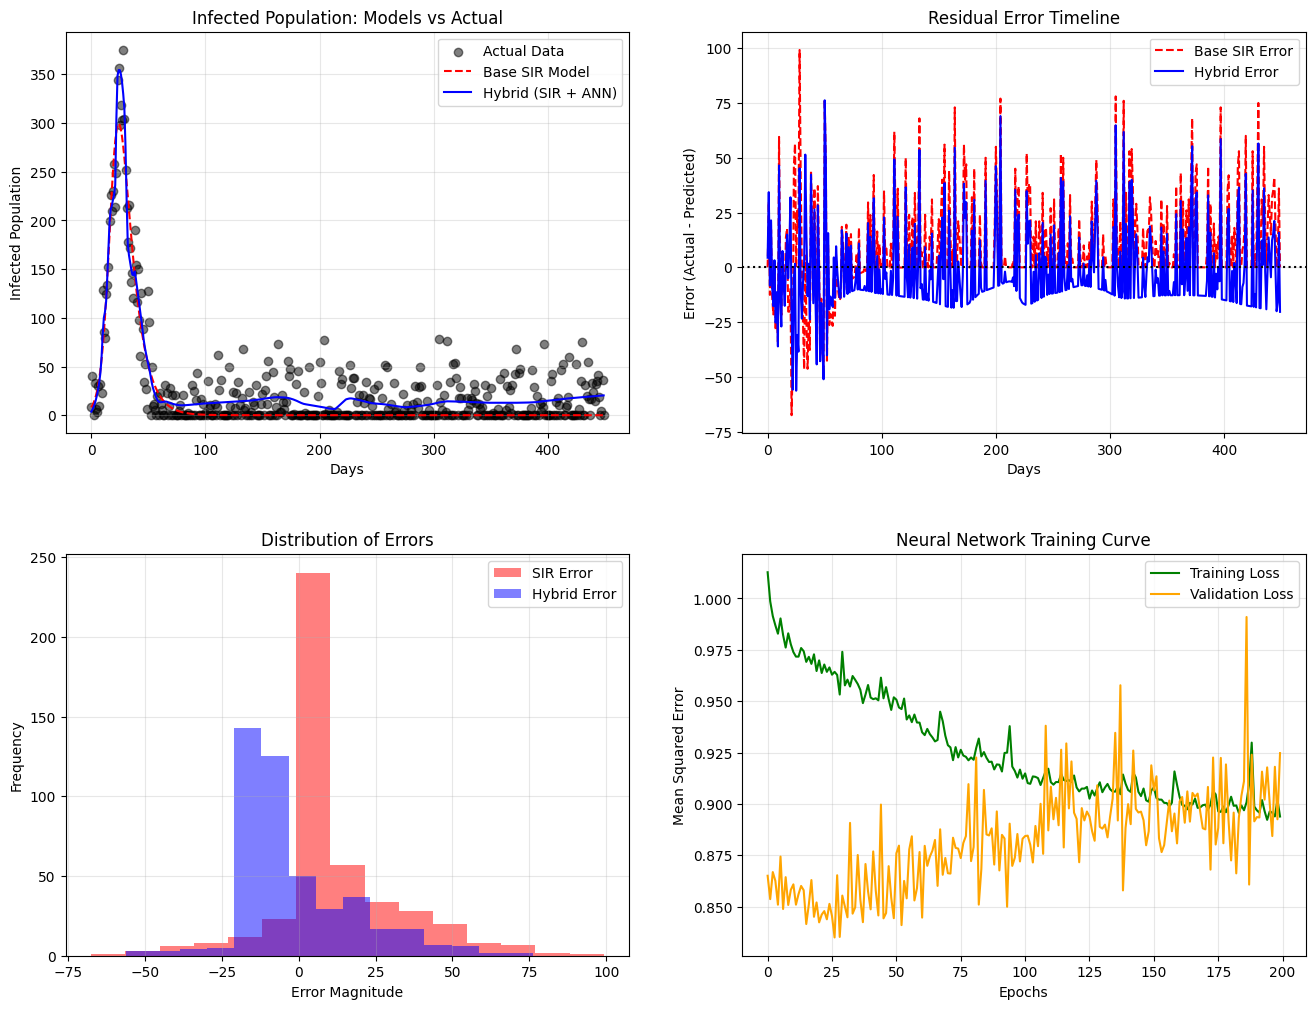

In [10]:
# Create a 2x2 grid of subplots for clean, consolidated visualization
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

# --- Plot 1: Model Trajectories ---
axs[0, 0].scatter(t, I_tru, color='black', label="Actual Data", alpha=0.5)
axs[0, 0].plot(t, I_sim, 'r--', label="Base SIR Model")
axs[0, 0].plot(t, I_hyb, 'b-', label="Hybrid (SIR + ANN)")
axs[0, 0].set_title("Infected Population: Models vs Actual")
axs[0, 0].set_xlabel("Days")
axs[0, 0].set_ylabel("Infected Population")
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# --- Plot 2: Residual Errors over Time ---
err_sir = I_tru - I_sim
err_hyb = I_tru - I_hyb

axs[0, 1].plot(t, err_sir, 'r--', label="Base SIR Error")
axs[0, 1].plot(t, err_hyb, 'b-', label="Hybrid Error")
axs[0, 1].axhline(0, color='black', linestyle=":")
axs[0, 1].set_title("Residual Error Timeline")
axs[0, 1].set_xlabel("Days")
axs[0, 1].set_ylabel("Error (Actual - Predicted)")
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# --- Plot 3: Error Distributions ---
axs[1, 0].hist(err_sir, bins=15, color='red', alpha=0.5, label="SIR Error")
axs[1, 0].hist(err_hyb, bins=15, color='blue', alpha=0.5, label="Hybrid Error")
axs[1, 0].set_title("Distribution of Errors")
axs[1, 0].set_xlabel("Error Magnitude")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# --- Plot 4: ANN Training Loss ---
axs[1, 1].plot(hist.history['loss'], 'g-', label="Training Loss")
axs[1, 1].plot(hist.history['val_loss'], 'orange', label="Validation Loss")
axs[1, 1].set_title("Neural Network Training Curve")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylabel("Mean Squared Error")
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

# Render the compiled grid
plt.show()